<a href="https://colab.research.google.com/github/ddy623/Kaggle-Projects/blob/main/Space_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [289]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [290]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [291]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data Science Project/train.csv'
df = pd.read_csv(file_path)
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [292]:
df.describe ()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [293]:
df.isnull().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


In [294]:
# Impute missing values in numerical columns with median from training data
numerical_cols_to_impute = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in numerical_cols_to_impute:
    median_val = df_train[col].median()
    df[col].fillna(median_val, inplace=True)

# Impute missing values in categorical columns with mode from training data
categorical_cols_to_impute = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin', 'Name']
for col in categorical_cols_to_impute:
    # Using .mode()[0] to get the first mode in case of multiple modes
    mode_val = df_train[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)

print("Missing values after imputation:")
display(df.isnull().sum())

Missing values after imputation:


/tmp/ipykernel_698/1270227461.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_698/1270227461.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

,0
PassengerId,0
HomePlanet,0
CryoSleep,0
Cabin,0
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0


In [295]:
df['HomePlanet'].value_counts()

,count
HomePlanet,
Earth,4803
Europa,2131
Mars,1759


the data shows that the majority of the passengers are from Earth.

In [296]:
df[['HomePlanet', 'PassengerId', 'Destination', 'Transported']].head()

,HomePlanet,PassengerId,Destination,Transported
0,Europa,0001_01,TRAPPIST-1e,False
1,Earth,0002_01,TRAPPIST-1e,True
2,Europa,0003_01,TRAPPIST-1e,False
3,Europa,0003_02,TRAPPIST-1e,False
4,Earth,0004_01,TRAPPIST-1e,True


In [297]:
transport_rate_by_homeplanet = df.groupby('HomePlanet')['Transported'].mean().reset_index()
display(transport_rate_by_homeplanet)

,HomePlanet,Transported
0,Earth,0.427649
1,Europa,0.658846
2,Mars,0.523024


/tmp/ipykernel_698/1145169388.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='HomePlanet', y='Transported', data=transport_rate_by_homeplanet, palette='viridis')


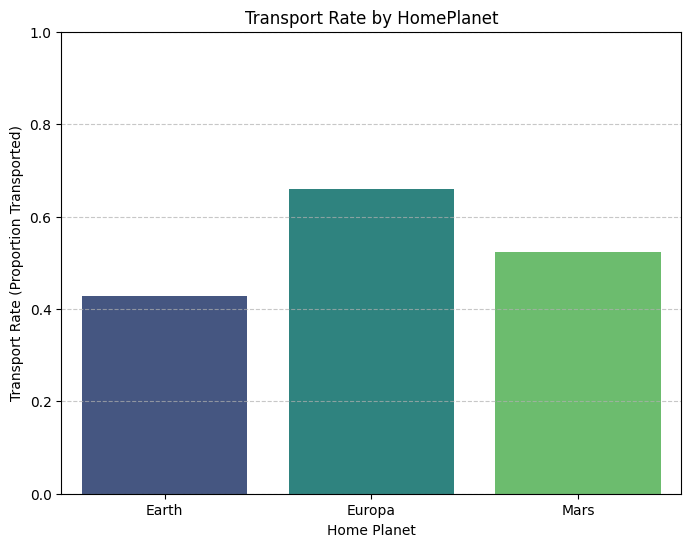

In [298]:
plt.figure(figsize=(8, 6))
sns.barplot(x='HomePlanet', y='Transported', data=transport_rate_by_homeplanet, palette='viridis')
plt.title('Transport Rate by HomePlanet')
plt.xlabel('Home Planet')
plt.ylabel('Transport Rate (Proportion Transported)')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for proportion
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Based upon the data, Europa has the highest transport rate, followed by Mars and then Earth.

Is there a correlation with the deck chosen and a person being transported?

In [299]:
df['Deck'] = df['Cabin'].apply(lambda x: x[0] if pd.notna(x) else 'Unknown')
deck_transport_rate = df.groupby('Deck')['Transported'].mean().reset_index()
display(deck_transport_rate)
print("Decks B and C were considered 'premium' as they had the highest transport rates among all decks.")

,Deck,Transported
0,A,0.496094
1,B,0.734275
2,C,0.680054
3,D,0.433054
4,E,0.357306
5,F,0.439871
6,G,0.515228
7,T,0.200000


Decks B and C were considered 'premium' as they had the highest transport rates among all decks.


In [300]:
premium_decks = ['B', 'C']

# Filter for passengers in premium decks using df
df_premium_decks = df[df['Deck'].isin(premium_decks)].copy()

# Count people in premium decks
num_people_premium_decks = df_premium_decks.shape[0]
print(f"Number of people in premium decks (B and C): {num_people_premium_decks}")

# Calculate average amenity usage for people in premium decks
amenities = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
average_amenities_premium = df_premium_decks[amenities].mean()

print("\nAverage amenity usage for people in premium decks:")
display(average_amenities_premium)

Number of people in premium decks (B and C): 1526

Average amenity usage for people in premium decks:


,0
RoomService,130.098296
FoodCourt,1507.814548
ShoppingMall,159.978375
Spa,807.924640
VRDeck,898.701835


Is there a correlation with cabin size and a person being transported?

In [301]:
# Extract the deck from the 'Cabin' column (e.g., 'B/0/P' -> 'B')
# Fill NaN values in 'Cabin' with 'Unknown' before extracting the first letter
df['Deck'] = df['Cabin'].apply(lambda x: x[0] if pd.notna(x) else 'Unknown')

# Calculate the transport rate by 'Deck'
deck_transport_rate = df.groupby('Deck')['Transported'].mean().reset_index()
display(deck_transport_rate)

,Deck,Transported
0,A,0.496094
1,B,0.734275
2,C,0.680054
3,D,0.433054
4,E,0.357306
5,F,0.439871
6,G,0.515228
7,T,0.200000


/tmp/ipykernel_698/2976795483.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Deck', y='Transported', data=deck_transport_rate, palette='viridis')


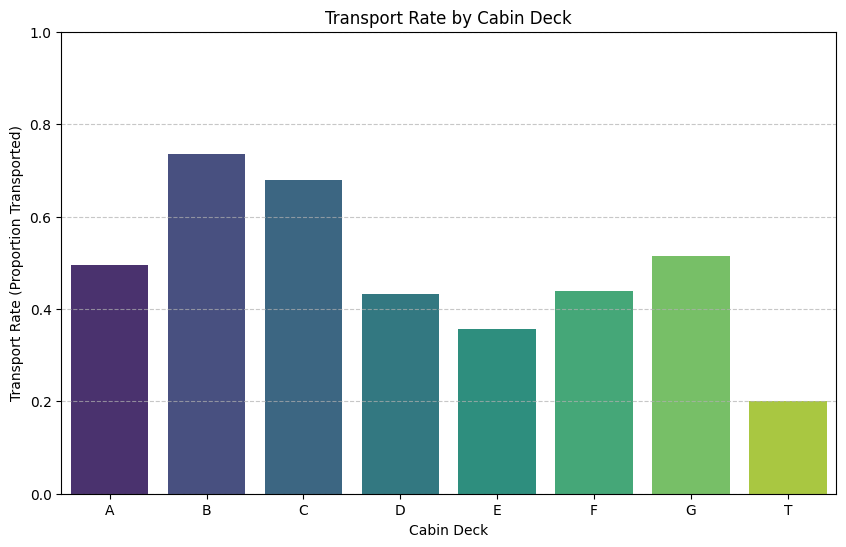

In [302]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Deck', y='Transported', data=deck_transport_rate, palette='viridis')
plt.title('Transport Rate by Cabin Deck')
plt.xlabel('Cabin Deck')
plt.ylabel('Transport Rate (Proportion Transported)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Deck B and C were more likely to be transported than any other deck.

### Correlation between VIP Status and Transported Status

In [303]:
# Calculate the transport rate by 'VIP' status
vip_transport_rate = df.groupby('VIP')['Transported'].mean().reset_index()
display(vip_transport_rate)

,VIP,Transported
0,False,0.506475
1,True,0.381910


/tmp/ipykernel_698/223940778.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='VIP', y='Transported', data=vip_transport_rate, palette='cividis')


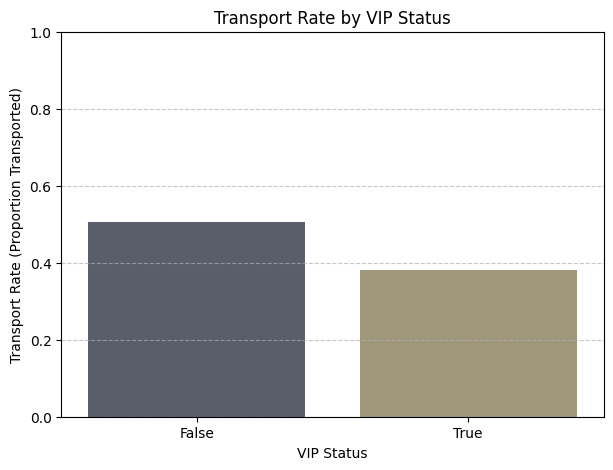

In [304]:

plt.figure(figsize=(7, 5))
sns.barplot(x='VIP', y='Transported', data=vip_transport_rate, palette='cividis')
plt.title('Transport Rate by VIP Status')
plt.xlabel('VIP Status')
plt.ylabel('Transport Rate (Proportion Transported)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [305]:
cryosleep_transport_rate = df.groupby('CryoSleep')['Transported'].mean().reset_index()
display(cryosleep_transport_rate)

,CryoSleep,Transported
0,False,0.335042
1,True,0.817583


This table shows the proportion of transported passengers for those who used CryoSleep and those who did not. A significant difference in these proportions would indicate there is a high correlation of those who used cryosleep and were transported.

/tmp/ipykernel_698/3614522816.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CryoSleep', y='Transported', data=cryosleep_transport_rate, palette='deep')


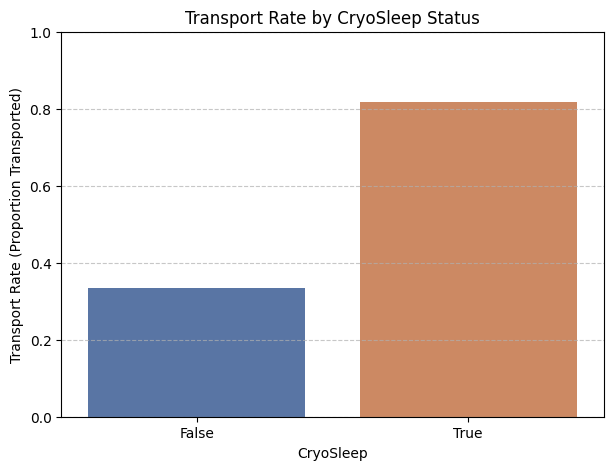

In [306]:

plt.figure(figsize=(7, 5))
sns.barplot(x='CryoSleep', y='Transported', data=cryosleep_transport_rate, palette='deep')
plt.title('Transport Rate by CryoSleep Status')
plt.xlabel('CryoSleep')
plt.ylabel('Transport Rate (Proportion Transported)')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for proportion
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Age group among the passengers

In [307]:
display(df['Age'].head())

,Age
0,39.0
1,24.0
2,58.0
3,33.0
4,16.0


In [308]:
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)
age_group_counts = df['AgeGroup'].value_counts().reindex(age_labels)
display(age_group_counts)

,count
AgeGroup,
Child,765
Teen,780
Young Adult,4464
Adult,2430
Senior,254


/tmp/ipykernel_698/3275978906.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='viridis', order=age_labels)


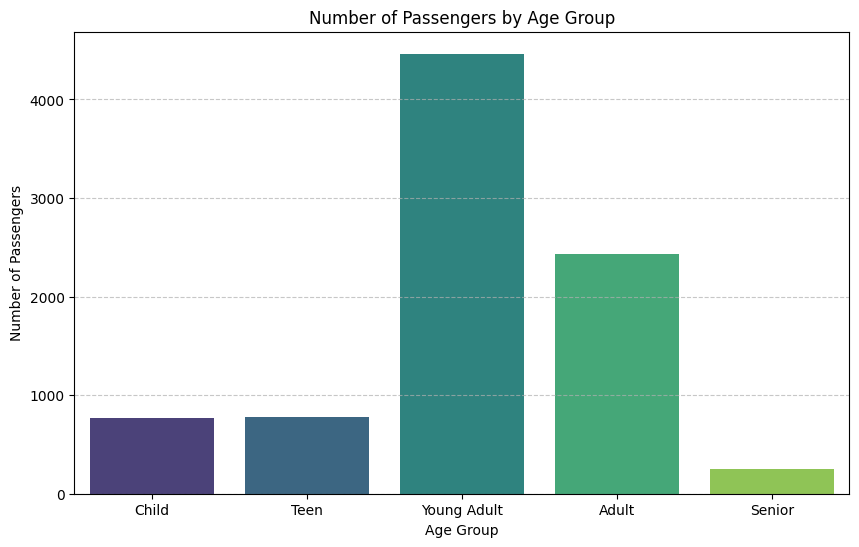

In [309]:
plt.figure(figsize=(10, 6))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='viridis', order=age_labels)
plt.title('Number of Passengers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Passengers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The data show that many of the passengers were Young Adults.

### Correlation between Age and Transported Status

In [310]:
# Create age bins for analysis
age_bins = [0, 12, 18, 35, 60, 100] # Child, Teen, Young Adult, Adult, Senior
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

# Calculate the transport rate by 'AgeGroup' using df_train_processed
age_transport_rate = df_train_processed.groupby('AgeGroup')['Transported'].mean().reset_index()
display(age_transport_rate)

/tmp/ipykernel_698/339558512.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_transport_rate = df_train_processed.groupby('AgeGroup')['Transported'].mean().reset_index()


,AgeGroup,Transported
0,Child,0.699346
1,Teen,0.561538
2,Young Adult,0.469534
3,Adult,0.489712
4,Senior,0.468504


/tmp/ipykernel_698/1605107813.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AgeGroup', y='Transported', data=age_transport_rate, palette='viridis', order=age_labels)


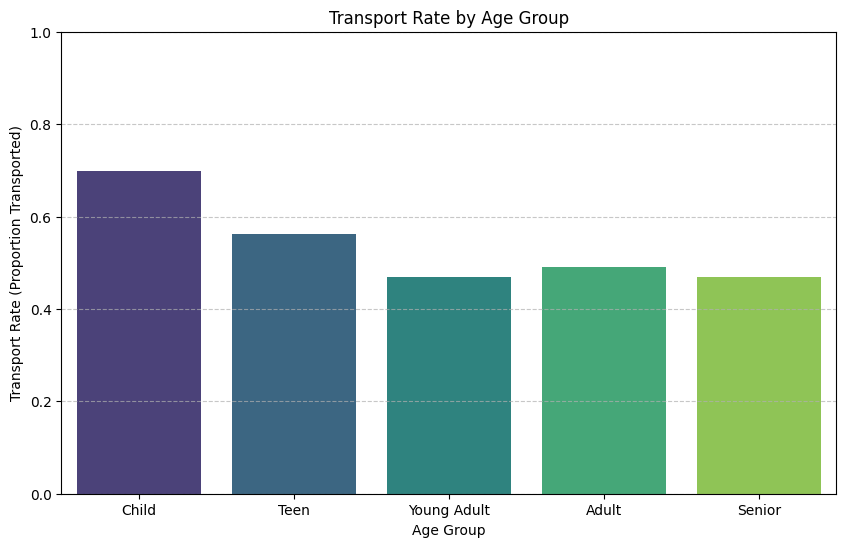

In [311]:
plt.figure(figsize=(10, 6))
sns.barplot(x='AgeGroup', y='Transported', data=age_transport_rate, palette='viridis', order=age_labels)
plt.title('Transport Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Transport Rate (Proportion Transported)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The data shows that children were more likely to be transported than any other age group.  

Let's examine the test data.

In [312]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data Science Project/test (1).csv'
df = pd.read_csv(file_path)
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


### Train-Validation Split for Model Evaluation

Since the provided `test.csv` does not contain the `Transported` column, we cannot use it to evaluate our model's performance directly. Instead, we'll split our `df_train_encoded` (which is the preprocessed original training data) into a new training set and a validation set. This validation set will act as our "unseen data" for evaluating how well our model generalizes before making predictions on the true test data.

In [313]:
# Split the df_train_encoded into training and validation sets
X = df_train_encoded.drop('Transported', axis=1)
y = df_train_encoded['Transported'].astype(int)

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train_split: {X_train_split.shape}")
print(f"Shape of y_train_split: {y_train_split.shape}")
print(f"Shape of X_val_split: {X_val_split.shape}")
print(f"Shape of y_val_split: {y_val_split.shape}")

Shape of X_train_split: (6954, 24)
Shape of y_train_split: (6954,)
Shape of X_val_split: (1739, 24)
Shape of y_val_split: (1739,)


In [314]:
model_split = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_split.fit(X_train_split, y_train_split)

train_split_accuracy = model_split.score(X_train_split, y_train_split)
print(f"New Model Training Data Accuracy (from split): {train_split_accuracy:.4f}")

New Model Training Data Accuracy (from split): 0.9395


In [315]:
val_accuracy = model_split.score(X_val_split, y_val_split)
print(f"New Model Validation Data Accuracy (from split): {val_accuracy:.4f}")

New Model Validation Data Accuracy (from split): 0.7901


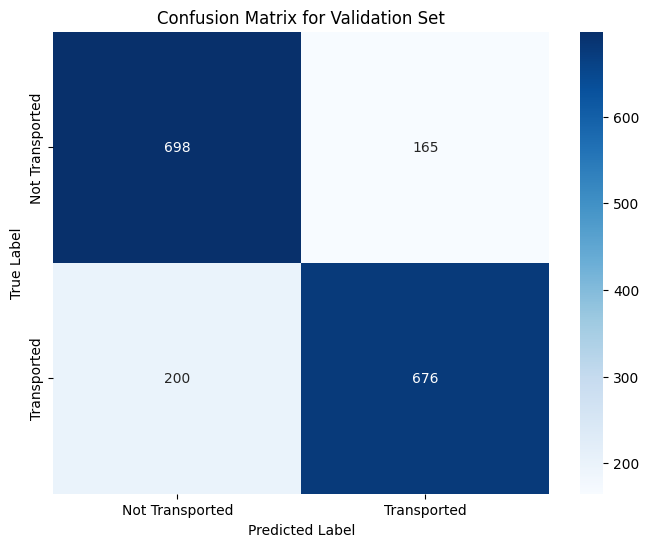

In [316]:
# Make predictions on the validation set
y_pred_val = model_split.predict(X_val_split)

# Calculate the confusion matrix
cm = confusion_matrix(y_val_split, y_pred_val)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Transported', 'Transported'],
            yticklabels=['Not Transported', 'Transported'])
plt.title('Confusion Matrix for Validation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [317]:
from xgboost import XGBClassifier

# Initialize and train an XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_split, y_train_split)

# Get feature importances from the XGBoost model
xgb_feature_importances = pd.Series(xgb_model.feature_importances_, index=X_train_split.columns).sort_values(ascending=False)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:34:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Show how features impact being transported

Top Features Determining Transportation Profile (XGBoost):


,0
CryoSleep,0.536097
Deck_G,0.109995
Deck_E,0.046579
HomePlanet_Europa,0.041552
HomePlanet_Mars,0.026250
VRDeck,0.022922
Spa,0.022801
Deck_F,0.021443
RoomService,0.020206
Deck_Unknown,0.019794


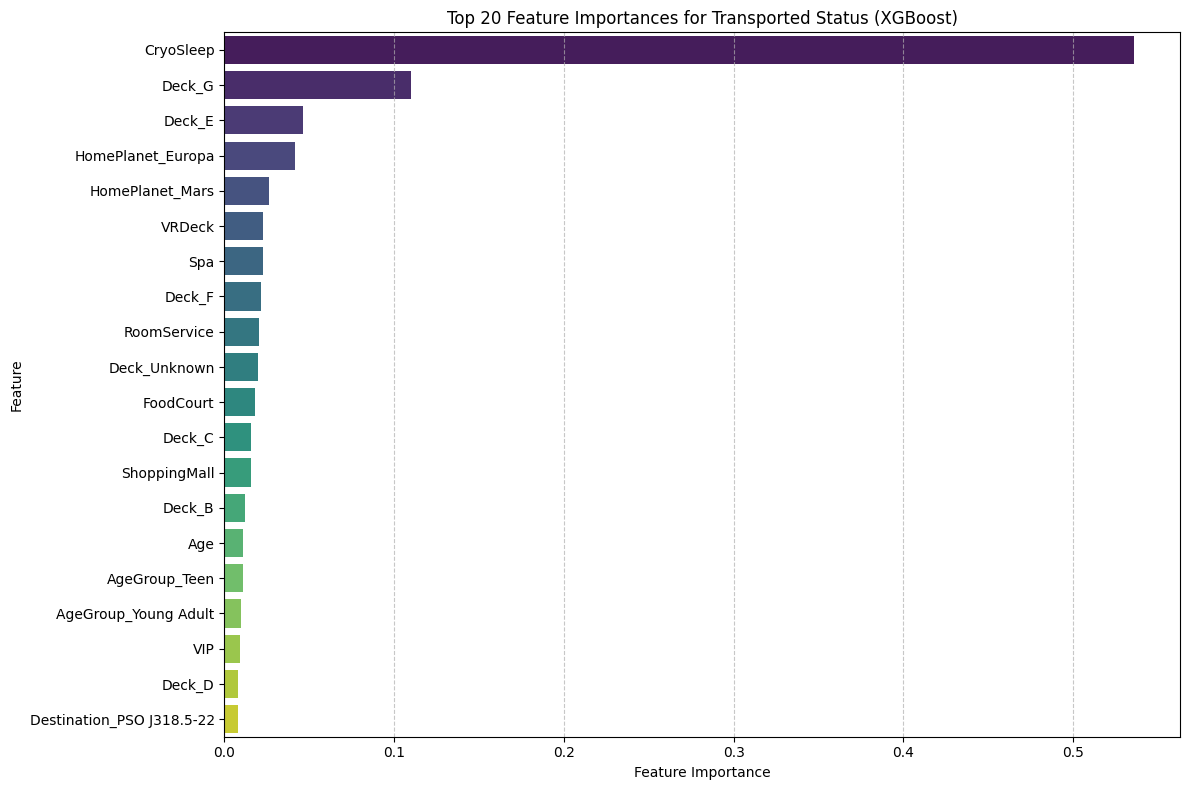

In [318]:
print("Top Features Determining Transportation Profile (XGBoost):")
display(xgb_feature_importances.head(20))

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=xgb_feature_importances.head(20).values, y=xgb_feature_importances.head(20).index, palette='viridis', hue=xgb_feature_importances.head(20).index, legend=False)
plt.title('Top 20 Feature Importances for Transported Status (XGBoost)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [319]:
feature_importances = pd.Series(model_split.feature_importances_, index=X_train_split.columns).sort_values(ascending=False)

Top Features Determining Transportation Profile:


,0
Age,0.148239
Spa,0.129640
RoomService,0.114246
VRDeck,0.114130
CryoSleep,0.111660
FoodCourt,0.110156
ShoppingMall,0.097435
HomePlanet_Europa,0.023876
Deck_G,0.021289
HomePlanet_Mars,0.019623


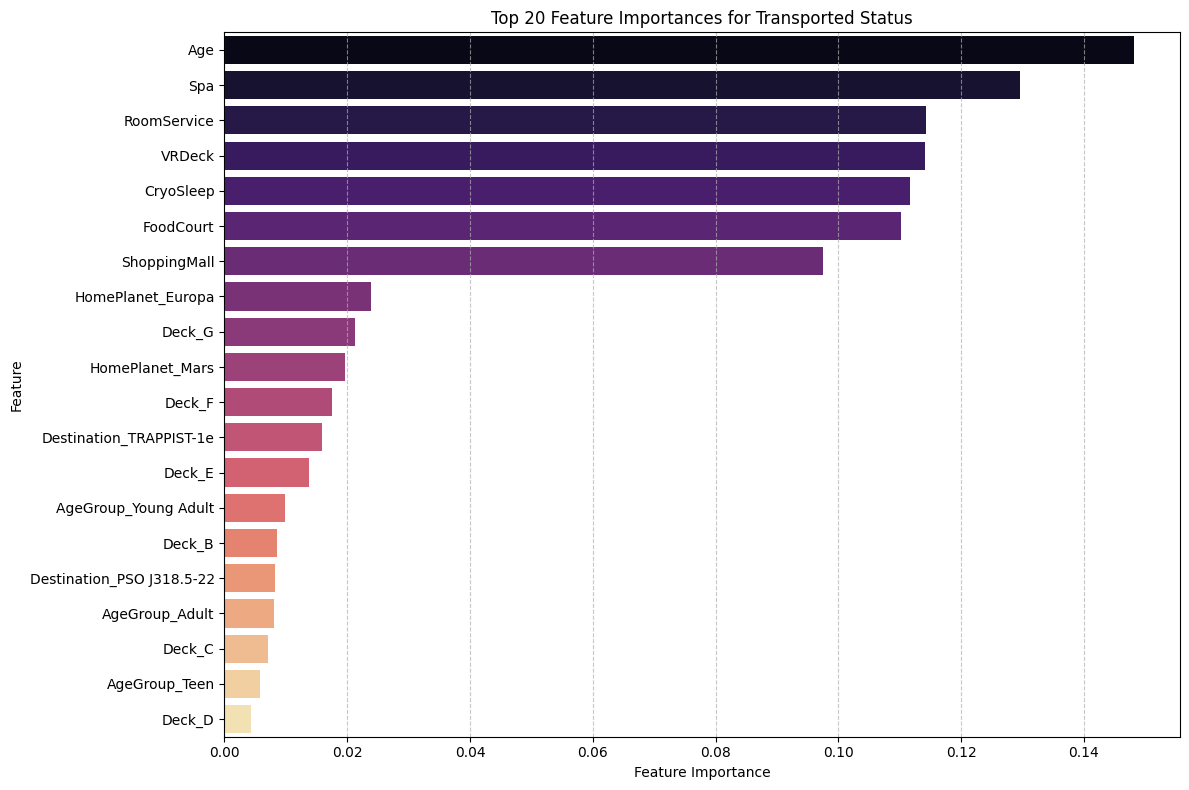

In [320]:
print("Top Features Determining Transportation Profile:")
display(feature_importances.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.head(20).values, y=feature_importances.head(20).index, palette='magma', hue=feature_importances.head(20).index, legend=False)
plt.title('Top 20 Feature Importances for Transported Status')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [321]:
total_passengers = df_train.shape[0]
total_transported = df_train['Transported'].sum()

print(f"Total Passengers: {total_passengers}")
print(f"Total Transported: {total_transported}")

Total Passengers: 8693
Total Transported: 4378


Based on the data, age (e.g. child), using amenities such as the spa and vrdeck were strong indicators of whether someone was transported.  

The least indicators were Deck D, Teens and Adults.

Overall, the data showed that there were 8,693 passengers aboard with the majority of the passengers were young adults.  Among the 8.693 passengers,4378 were transported.
The data show that a passenger was highly likely to be transported if they were a child or from Europa, in CryoSleep, spending money on amenities, and being located on a 'premium' deck like B or C.Non-VIP passengers were more likely to be transported (roughly 51% than VIP passengers, which was 38%).  

Based up maching learning, the models show that a combination of demographic factors such as age, lifestyle choices and physical attributes such as home planet, and deck are the strongest indicators of whether a person was transported.

Moreover, the confusion matrix was able to predict that 676 passengers were transported and predicted that 698 passengers were not transported with accuracy.



In [322]:
test_file_path = '/content/drive/MyDrive/Colab Notebooks/Data Science Project/test (1).csv'
df_test_original = pd.read_csv(test_file_path)


In [323]:
# Convert numerical predictions (0, 1) to boolean (False, True)
predictions_boolean = test_predictions.astype(bool)

# Create a submission DataFrame
submission_df = pd.DataFrame({
    'PassengerId': df_test_original['PassengerId'],
    'Transported': predictions_boolean
})

# Display the first few rows of the submission DataFrame
display(submission_df.head())


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False


In [324]:
# Save the submission DataFrame to a CSV file
submission_file_path = '/content/drive/MyDrive/Colab Notebooks/Data Science Project/submission.csv'
submission_df.to_csv(submission_file_path, index=False)

print(f"Submission file saved to: {submission_file_path}")


Submission file saved to: /content/drive/MyDrive/Colab Notebooks/Data Science Project/submission.csv
